# MODELIZACIÓN PARA NO SUPERVISADO

## IMPORTAR PAQUETES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score

from sklearn.model_selection import GridSearchCV

#Autocompletar rápido
%config IPCompleter.greedy=True

#Desactivar la notación científica
pd.options.display.float_format = '{:.2f}'.format

#Desactivar los warnings
import warnings
warnings.filterwarnings("ignore")

## IMPORTAR LOS DATOS

Sustituir la ruta del proyecto.

In [2]:
ruta_proyecto = 'C:/Users/Lenovo/Documents/portafolio_ds/automation/LEAD_KAGGLE'

Nombres de los archivos de datos.

In [3]:
nombre_df = 'df_tablon.pickle'

Cargar los datos.

In [82]:
df = pd.read_pickle(ruta_proyecto + '/02_Datos/03_Trabajo/' + nombre_df)

La celda de abajo es parte del proceso de ir probando configuraciones para encontrar perfiles claros en la segmentación.

In [83]:
df.drop(columns = [col for col in df.columns if col.startswith('lead_source') 
                   or col.startswith('country')  
                   #or col.startswith('last_notable_activity') 
                   or col.startswith('city') 
                   or col.startswith('specialization') 
                   or col.startswith('asymmetrique_activity_index_oe') 
                   or col.startswith('asymmetrique_profile_index_oe') 
                   #or col.startswith('tags') 
                   or col.startswith('last_activity')
                   or col.startswith('page_views_per_visit_mms')
                   or col.startswith('total_visits_mms')
                   or col.startswith('asymmetrique_activity_score_mms')
                   or col.startswith('asymmetrique_profile_score_mms')
                   or col.startswith('lead_number')], inplace = True)

## MODELIZAR

### Crear el espacio de soluciones

In [84]:
min_k = 3
max_k = 7

soluciones = list(range(min_k,max_k))

### Crear listas para guardar la salida de cada métrica

In [85]:
codo = []
silueta = []
calins = []
davies = []

### Analizar el espacio de soluciones

In [86]:
for solucion in soluciones:
    
    #Instanciar
    cluster = KMeans(n_clusters = solucion, n_init=10)
    
    #Entrenar
    cluster.fit(df)
    
    #Recoger las métricas
    codo.append(cluster.inertia_)
    silueta.append(silhouette_score(df, cluster.labels_))
    calins.append(calinski_harabasz_score(df, cluster.labels_))
    davies.append(davies_bouldin_score(df, cluster.labels_))

### Identificar la mejor solucion

#### Analizar las métricas

In [87]:
metricas = pd.DataFrame({'Solucion':soluciones,
              'Codo': codo,
              'Silueta':silueta,
              'Calins':calins,           
              'Davies':davies}).set_index('Solucion')

metricas

,Codo,Silueta,Calins,Davies
Solucion,,,,
3,10514.95,0.22,1310.11,1.81
4,9776.56,0.20,1088.65,1.81
5,9027.09,0.21,1007.32,1.87
6,8390.84,0.23,956.81,1.73


#### Analizar los gráficos

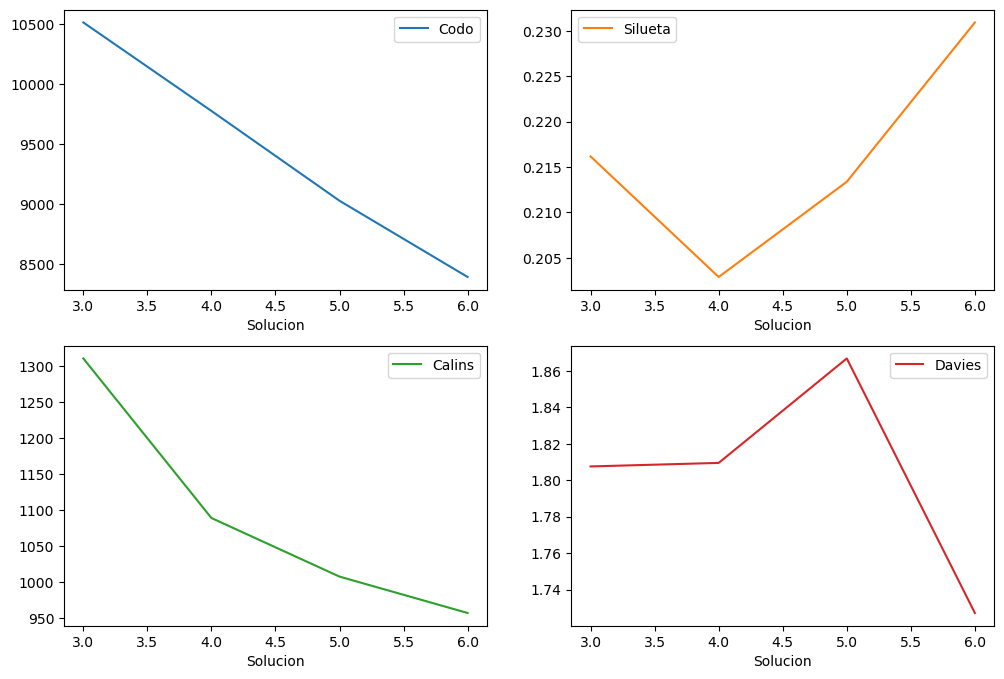

In [88]:
metricas.plot(subplots = True, figsize = (12,8), layout = (2,2), sharex = False)
plt.show();

### Segmentación final con la mejor solucion

In [92]:
mejor_solucion = 6


#Instanciar
cluster = KMeans(n_clusters = mejor_solucion, n_init=10)
    
#Entrenar
cluster.fit(df)

KMeans(n_clusters=6, n_init=10)

## EVALUAR

### Calcular el segmento en entrenamiento y en validación

In [93]:
df['segmento'] = cluster.predict(df)

## PERFILAR LOS SEGMENTOS

In [94]:
df.groupby('segmento').mean().T \
    .style.highlight_max(color = 'lightgreen', axis = 1) \
    .highlight_min(color = 'red', axis = 1)

segmento,0,1,2,3,4,5
lead_origin_API,0.000000,0.000000,0.999030,0.306836,1.000000,0.000000
lead_origin_Landing Page Submission,0.968028,0.875637,0.000000,0.427663,0.000000,0.987500
lead_origin_Lead Add Form,0.023979,0.100917,0.000970,0.259141,0.000000,0.012500
lead_origin_OTHER,0.007993,0.023445,0.000000,0.006359,0.000000,0.000000
what_is_your_current_occupation_OTHER,0.001776,0.005097,0.000000,0.009539,0.002033,0.000000
what_is_your_current_occupation_Student,0.020426,0.019368,0.025218,0.037361,0.022358,0.005357
what_is_your_current_occupation_Unemployed,0.956483,0.951070,0.972842,0.634340,0.964431,0.994643
what_is_your_current_occupation_Working Professional,0.021314,0.024465,0.001940,0.318760,0.011179,0.000000
tags_Already a student,0.072824,0.065240,0.053346,0.000000,0.065041,0.035714
tags_Busy,0.017762,0.022426,0.012609,0.031797,0.007114,0.039286


In [95]:
df.segmento.value_counts(normalize=True)

segmento
3   0.21
0   0.19
2   0.17
4   0.17
1   0.17
5   0.09
Name: proportion, dtype: float64

21% de los leads que estamos generando son de muy buena calidad.

Se llegó a esta configuración después de realizar distintas pruebas para encontrar la opción que fuera capaz de proveer un perfil claro para cada segmento.